<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import GRU, Dense


In [ ]:
# Load CSV
df = pd.read_csv('/content/allDataMean.csv')

In [ ]:
# Select one column for univariate GRU
data = df[['allDataMean1']].values

In [ ]:
# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# Reshape for GRU [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], seq_length, 1))
X_test = X_test.reshape((X_test.shape[0], seq_length, 1))

In [ ]:
# Build GRU model
gru_model = Sequential([
    GRU(64, input_shape=(seq_length, 1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the GRU model
history = gru_model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)


Epoch 1/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0062 - val_loss: 1.7754e-04
Epoch 2/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.2088e-04 - val_loss: 1.4943e-04
Epoch 3/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.0351e-04 - val_loss: 1.6135e-04
Epoch 4/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 8.6542e-05 - val_loss: 1.2295e-04
Epoch 5/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.1343e-05 - val_loss: 2.2967e-04
Epoch 6/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 7.5156e-05 - val_loss: 1.0081e-04
Epoch 7/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.7423e-05 - val_loss: 1.0484e-04
Epoch 8/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8.1095e-05 - val_loss: 1.0096e-04
Epoch 9/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 8.2412e-05 - val_loss: 1.0283e-04
Epoch 10/20
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.4689e-05 - val_loss: 1.0140e-04
Epoch 11/20
2075/2075 ━━━━━━━━━━━

In [ ]:
# Predict
y_pred = gru_model.predict(X_test)

# Invert scaling
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"GRU Model - MAE: {mae:.4f}")
print(f"GRU Model - MSE: {mse:.4f}")
print(f"GRU Model - R² Score: {r2:.4f}")


GRU Model - MAE: 0.0061
GRU Model - MSE: 0.0038
GRU Model - R² Score: 0.9989


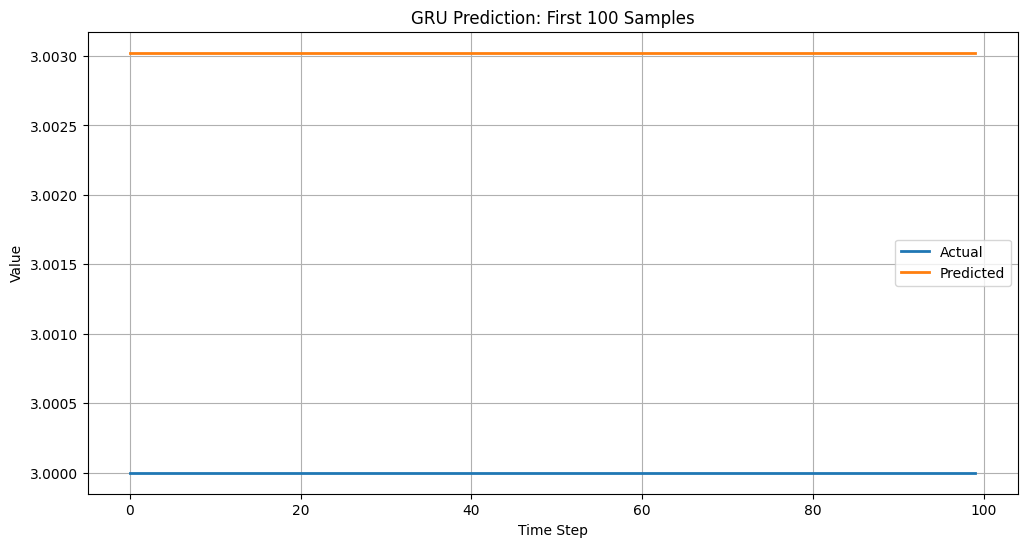

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual', linewidth=2)
plt.plot(y_pred_inv[:100], label='Predicted', linewidth=2)
plt.title('GRU Prediction: First 100 Samples')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


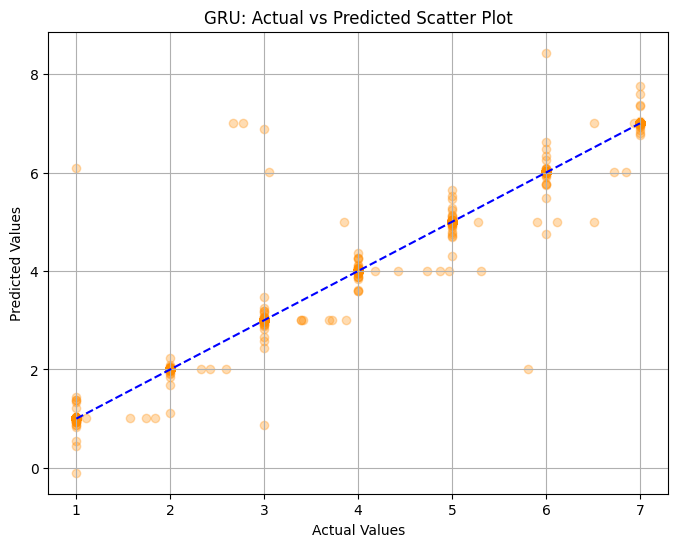

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.3, color='darkorange')
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], 'b--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("GRU: Actual vs Predicted Scatter Plot")
plt.grid(True)
plt.show()


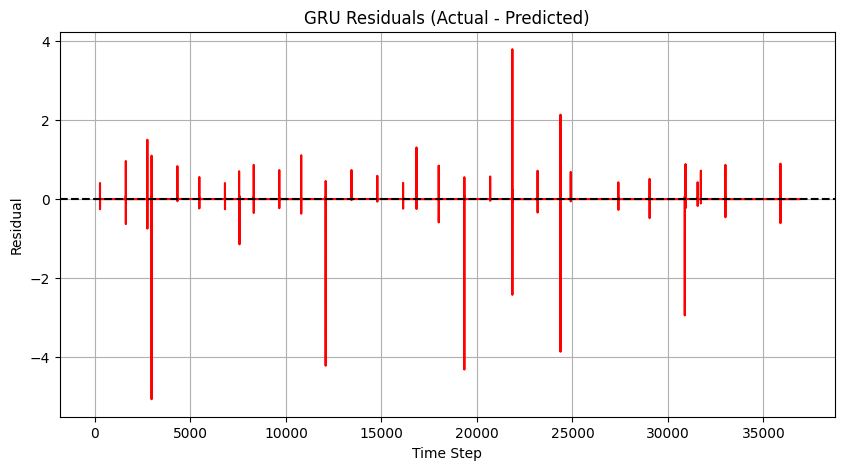

In [ ]:
residuals = y_test_inv.flatten() - y_pred_inv.flatten()

plt.figure(figsize=(10, 5))
plt.plot(residuals, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("GRU Residuals (Actual - Predicted)")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.grid(True)
plt.show()


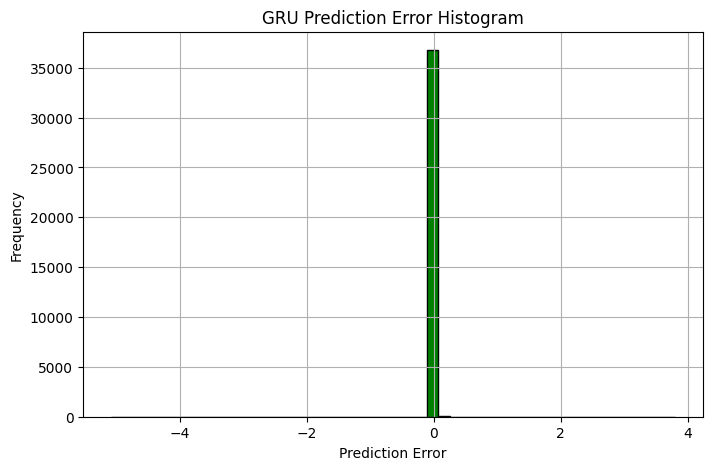

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='green', edgecolor='black')
plt.title("GRU Prediction Error Histogram")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
